# Preparations

In [72]:
import pandas as pd
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, zscore, median_abs_deviation, f_oneway, kruskal, gaussian_kde, chi2, norm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
import numpy as np
import re 
import seaborn as sns
import math
from math import erf, sqrt
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import scikit_posthocs as sp
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from itertools import combinations, product
import patchworklib as pw
from matplotlib.gridspec import GridSpec
import string
import pylab 
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from openpyxl.utils import get_column_letter
from textwrap import fill

import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f as f_dist
from scipy.stats import t as t_dist
from typing import Optional
from matplotlib.colors import TwoSlopeNorm




from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


In [73]:
# Load dataset
data = pd.read_excel("./replicates_Ki_checked_for_statistic.xlsx")


## Data prep

In [74]:
print(data["concentration radioligand (nM)"].dtype) # cannot use object for numbers- needs to be converted to float

object


In [75]:
#convert to float
# Convert radioligand concentration column to numeric values;
# non-numeric entries are coerced to NaN to ensure compatibility with statistical analyses
data["concentration radioligand (nM)"] = pd.to_numeric(data["concentration radioligand (nM)"].copy(), errors="coerce")

In [76]:
print(data["concentration radioligand (nM)"].dtype) #check if type has changed to float

float64


## Subdataframes for each investigated compound


In [77]:
Rimonabant_df = data[data.pubchem_cid == 104850.0].copy() 
WIN_df = data[data.pubchem_cid == 5311501.0].copy() 
CP_df = data[data.pubchem_cid == 104895.0].copy() 
Anandamide_df = data[data.pubchem_cid == 5281969.0].copy() 
THC9_df = data[data.pubchem_cid == 16078.0].copy()
JWH018_df = data[data.pubchem_cid == 10382701.0].copy()
SR_df = data[data.pubchem_cid == 3081355.0].copy()
THC8_df = data[data.pubchem_cid == 638026.0].copy()
CHEMBL_df = data[data.pubchem_cid == 44208932.0].copy()
JWH133_df = data[data.pubchem_cid == 6918505.0].copy() 

### Anandamide/ PMSF outlier investigation


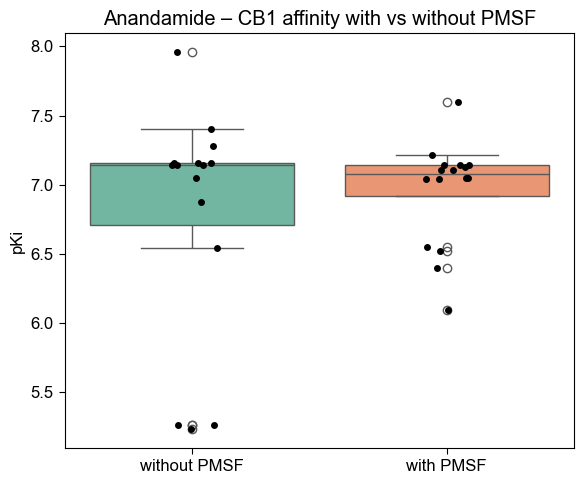

In [78]:

df = Anandamide_df.copy()

# -----------------------------
# 1) PMSF Variable erzeugen
# -----------------------------
df["PMSF"] = df["substance_added"].str.contains("pmsf", case=False, na=False)

# Label für Plot
df["PMSF_label"] = df["PMSF"].map({True: "with PMSF", False: "without PMSF"})

# -----------------------------
# 2) Plot (pKi)
# -----------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="PMSF_label",
    y="value_pKi",
    palette="Set2"
)

sns.stripplot(
    data=df,
    x="PMSF_label",
    y="value_pKi",
    color="black",
    size=5,
    jitter=True
)

plt.ylabel("pKi")
plt.xlabel("")
plt.title("Anandamide – CB1 affinity with vs without PMSF")

plt.tight_layout()
plt.show()

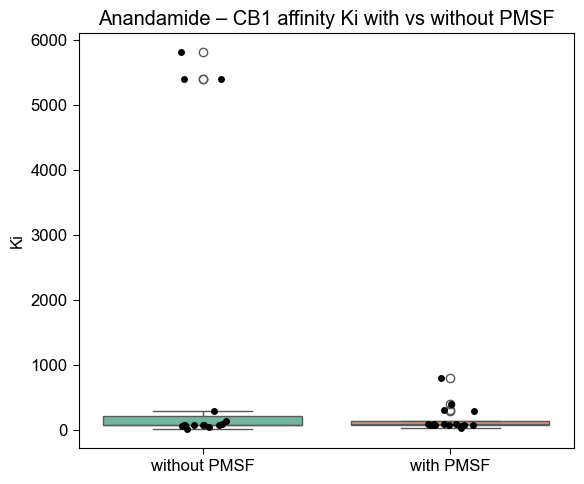

In [79]:

df = Anandamide_df.copy()

# -----------------------------
# 1) PMSF Variable erzeugen
# -----------------------------
df["PMSF"] = df["substance_added"].str.contains("pmsf", case=False, na=False)

# Label für Plot
df["PMSF_label"] = df["PMSF"].map({True: "with PMSF", False: "without PMSF"})

# -----------------------------
# 2) Plot (pKi)
# -----------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="PMSF_label",
    y="value",
    palette="Set2"
)

sns.stripplot(
    data=df,
    x="PMSF_label",
    y="value",
    color="black",
    size=5,
    jitter=True
)

plt.ylabel("Ki")
plt.xlabel("")
plt.title("Anandamide – CB1 affinity Ki with vs without PMSF")

plt.tight_layout()
plt.show()

#### remove three anandamide outliers



In [80]:
Anandamide_df.loc[
    Anandamide_df["value"] > 5000,
    ["value", "value_pKi", "substance_added"]
]

,value,value_pKi,substance_added
217,5400.0,5.267606,NaN
218,5400.0,5.267606,NaN
220,5810.0,5.235824,NaN


In [81]:
data = data[
    ~(
        (data["pubchem_cid"] == 5281969.0) &
        (data["value"] > 5000)
    )
].reset_index(drop=True)

print("Remaining Anandamide values >5000 nM:")
print(
    data[
        (data["pubchem_cid"] == 5281969.0) &
        (data["value"] > 5000)
    ]
)

Remaining Anandamide values >5000 nM:
Empty DataFrame
Columns: [pubchem_cid, value, value_pKi, assay_name, assay_sub, assay_readout, substance_added, cell_membrane, cell_cleaned, receptor_species, g_protein, reference_substance, concentration radioligand (nM), Kd, incubation_time, temp]
Index: []


In [82]:
Anandamide_2_df = data[data.pubchem_cid == 5281969.0].copy() 

# Bilder für Paper Single Substances

## Histogramm

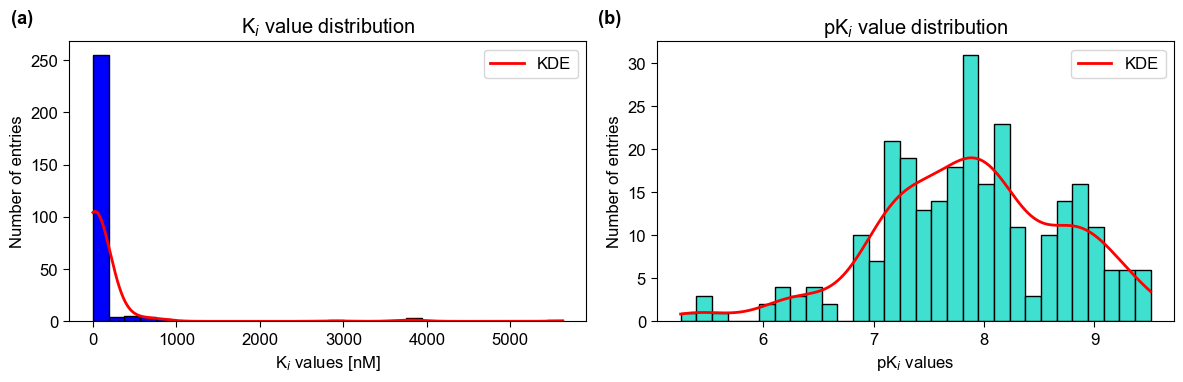

In [83]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Plot 1: Ki values
data_ki = data["value"]
counts_ki, bins_ki, _ = axes[0].hist(data_ki, bins=30, color='Blue', edgecolor='black')
axes[0].set_title('K$_{i}$ value distribution')
axes[0].set_xlabel('K$_{i}$ values [nM]')
axes[0].set_ylabel('Number of entries')

# KDE passend zur Histogramm-Skala
kde_ki = gaussian_kde(data_ki)
x_ki = np.linspace(data_ki.min(), data_ki.max(), 500)
bin_width_ki = bins_ki[1] - bins_ki[0]
axes[0].plot(x_ki, kde_ki(x_ki) * len(data_ki) * bin_width_ki, color="red", lw=2, label="KDE")
axes[0].legend(loc="upper right")

# Plot 2: pKi values
data_pki = data["value_pKi"]
counts_pki, bins_pki, _ = axes[1].hist(data_pki, bins=30, color='Turquoise', edgecolor='black')
axes[1].set_title('pK$_{i}$ value distribution')
axes[1].set_xlabel('pK$_{i}$ values')
axes[1].set_ylabel('Number of entries')

# KDE passend zur Histogramm-Skala
kde_pki = gaussian_kde(data_pki)
x_pki = np.linspace(data_pki.min(), data_pki.max(), 500)
bin_width_pki = bins_pki[1] - bins_pki[0]
axes[1].plot(x_pki, kde_pki(x_pki) * len(data_pki) * bin_width_pki, color="red", lw=2, label="KDE")
axes[1].legend(loc="upper right")

# Adjust positions relative to axes (negative y puts it slightly above the plot)
axes[0].text(-0.07, 1.05, "(a)", transform=axes[0].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")
axes[1].text(-0.07, 1.05, "(b)", transform=axes[1].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")

# Layout anpassen
plt.tight_layout()

# Save & show
plt.savefig("Histogram_Ki_and_pKi_with_KDE.png", dpi=300)
plt.show()

## QQ plot

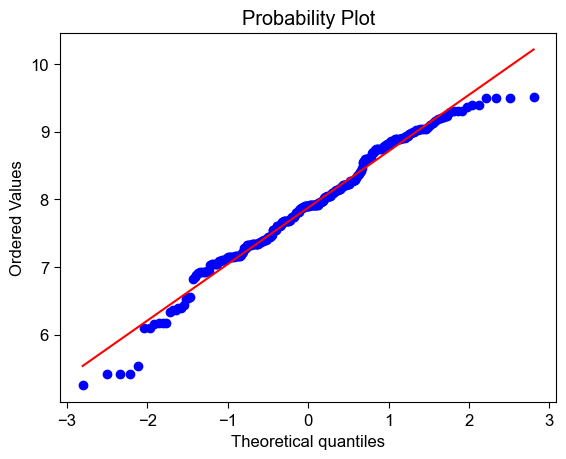

In [84]:
stats.probplot(data["value_pKi"], dist="norm", plot=pylab)
plt.savefig("QQ_plot_dataset_pKi.png", dpi=300)
pylab.show()

# LMM 

## LMM mit Multiple Imputation

In [85]:
# ============================================================
# Linear Mixed Model (LMM) for CB1 pKi
# with Multiple Imputation (MI) for numeric + categorical assay parameters
# ------------------------------------------------------------
# - Response: value_pKi
# - Fixed effects:
#     receptor_species
#     reference_substance
#     cell_cleaned
#     incubation_time
#     temp
#     log10_concentration_radioligand_nM
# - Random effect:
#     random intercept for pubchem_cid
# - Multiple imputation:
#     approximate MICE-style approach using IterativeImputer with posterior draws
# ============================================================


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
df_raw = data.copy()

Y_VAR = "value_pKi"
GROUP_VAR = "pubchem_cid"

CATEGORICAL_VARS = ["receptor_species", "reference_substance", "cell_cleaned"]
NUMERIC_VARS_RAW = ["incubation_time", "temp", "concentration radioligand (nM)"]

MI_M = 20
MI_MAX_ITER = 30
MI_RANDOM_SEED = 42

USE_REML_FINAL = True
FIT_NULL_MODEL = True  # useful for ICC / baseline variance structure

REFERENCE_LEVELS = {
    "receptor_species": "human",
    "reference_substance": "3HCP55940",  # robust match to observed spelling
    "cell_cleaned": "hek",
}

# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def rubin_pool_scalar(estimates, ses):
    """
    Rubin pooling for one scalar parameter across m imputations.
    Returns pooled estimate, pooled SE, z, p, within-var, between-var.
    """
    q = np.asarray(estimates, dtype=float)
    u = np.asarray(ses, dtype=float) ** 2
    m = len(q)

    qbar = q.mean()
    ubar = u.mean()
    b = q.var(ddof=1) if m > 1 else 0.0
    t = ubar + (1 + 1/m) * b
    se = np.sqrt(t)

    z = qbar / se if se > 0 else np.nan
    p = 2 * norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return qbar, se, z, p, ubar, b

def pool_fixed_effects(fe_params_list, fe_cov_list):
    """
    Rubin pooling for fixed effects only.
    Uses large-sample normal approximation for p-values.
    """
    coef_names = fe_params_list[0].index.tolist()
    rows = []

    for name in coef_names:
        ests = [p[name] for p in fe_params_list]
        ses = [np.sqrt(c.loc[name, name]) for c in fe_cov_list]

        qbar, se, z, p, ubar, b = rubin_pool_scalar(ests, ses)

        rows.append({
            "term": name,
            "estimate": qbar,
            "std_error": se,
            "z_approx": z,
            "p_value_approx": p,
            "ci_low_95": qbar - 1.96 * se,
            "ci_high_95": qbar + 1.96 * se,
            "within_var": ubar,
            "between_var": b
        })

    return pd.DataFrame(rows)

def extract_variance_summary(res_list):
    rows = []
    for i, res in enumerate(res_list, start=1):
        group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
        resid_var = float(res.scale)
        icc = group_var / (group_var + resid_var) if (group_var + resid_var) > 0 else np.nan

        rows.append({
            "imp": i,
            "group_var": group_var,
            "residual_var": resid_var,
            "ICC": icc
        })
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 2) CLEAN + PREP BASE DATA
# ------------------------------------------------------------
needed_cols = [Y_VAR, GROUP_VAR] + CATEGORICAL_VARS + NUMERIC_VARS_RAW
missing_needed = [c for c in needed_cols if c not in df_raw.columns]
if missing_needed:
    raise ValueError(f"Missing required columns: {missing_needed}")

df = df_raw[needed_cols].copy()
df = df.dropna(subset=[Y_VAR, GROUP_VAR]).copy()

# rename to safe column names
rename_cols = {c: make_safe(c) for c in df.columns}
df = df.rename(columns=rename_cols)

Y = make_safe(Y_VAR)
GROUP = make_safe(GROUP_VAR)

CATS = [make_safe(c) for c in CATEGORICAL_VARS]
NUMS_RAW_SAFE = [make_safe(c) for c in NUMERIC_VARS_RAW]

cat_map = dict(zip(CATEGORICAL_VARS, CATS))
num_raw_map = dict(zip(NUMERIC_VARS_RAW, NUMS_RAW_SAFE))

# categorical cleaning: use object/category, NOT pandas string dtype
for c in CATS:
    df[c] = df[c].astype("object")
    df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

# group variable
df[GROUP] = df[GROUP].astype("object")
df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

# numeric coercion
for c in NUMS_RAW_SAFE:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# create log10 radioligand concentration (<=0 -> NaN)
rad_col = make_safe("concentration radioligand (nM)")
df["log10_concentration_radioligand_nM"] = df[rad_col].where(df[rad_col] > 0, np.nan)
df["log10_concentration_radioligand_nM"] = np.log10(df["log10_concentration_radioligand_nM"])

NUMS = [make_safe("incubation_time"), make_safe("temp"), "log10_concentration_radioligand_nM"]

# robustly matched reference levels
observed_reference_levels = {}
for orig_name, safe_name in cat_map.items():
    observed = df[safe_name].dropna().astype(str).unique().tolist()
    desired = REFERENCE_LEVELS[orig_name]
    matched = match_reference_level(observed, desired)
    observed_reference_levels[safe_name] = matched

print("Matched reference levels:")
for k, v in observed_reference_levels.items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------
# 3) BUILD IMPUTATION MATRIX
# ------------------------------------------------------------
base_df = df[[Y, GROUP] + CATS + NUMS].copy()

missing_masks_numeric = {c: base_df[c].isna().copy() for c in NUMS}
missing_masks_categorical = {c: base_df[c].isna().copy() for c in CATS}

cat_levels = {}
cat_dummy_cols = {}

for c in CATS:
    levels = sorted(base_df[c].dropna().astype(str).unique().tolist())
    cat_levels[c] = levels

    dummies = pd.get_dummies(base_df[c], prefix=c, dtype=float)

    # important: rows with missing original category -> all dummy cols = NaN
    miss = base_df[c].isna()
    if dummies.shape[1] > 0:
        dummies.loc[miss, :] = np.nan

    cat_dummy_cols[c] = dummies.columns.tolist()
    base_df = pd.concat([base_df, dummies], axis=1)

# group dummies as auxiliary predictors only
group_dummies = pd.get_dummies(base_df[GROUP].astype(str), prefix="grp", dtype=float)
base_df = pd.concat([base_df, group_dummies], axis=1)

cat_dummy_all = [col for cols in cat_dummy_cols.values() for col in cols]
aux_cols = [Y] + group_dummies.columns.tolist()
imputation_cols = NUMS + cat_dummy_all + aux_cols

imp_df = base_df[imputation_cols].copy()

print("\nMissing values before MI:")
for c in NUMS:
    print(f"  numeric {c}: {int(missing_masks_numeric[c].sum())}")
for c in CATS:
    print(f"  categorical {c}: {int(missing_masks_categorical[c].sum())}")

# ------------------------------------------------------------
# 4) FIT IMPUTER
# ------------------------------------------------------------
imputer = IterativeImputer(
    max_iter=MI_MAX_ITER,
    sample_posterior=True,
    random_state=MI_RANDOM_SEED,
    skip_complete=False
)

imputer.fit(imp_df)

# ------------------------------------------------------------
# 5) MULTIPLE IMPUTATION DIAGNOSTICS
# ------------------------------------------------------------
def mi_diagnostics(imputer, imp_df, num_cols, cat_cols, cat_dummy_cols, base_df, n_draws=5):
    """
    Per-variable MI diagnostics.

    Numeric:
      - mean SD across imputations on originally missing cells

    Categorical:
      - share of rows whose imputed category changes across repeated draws
    """
    diagnostics = []
    draws = []

    for _ in range(n_draws):
        arr = imputer.transform(imp_df)
        draws.append(pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index))

    # numeric diagnostics
    for c in num_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "numeric",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        mat = np.column_stack([d.loc[miss, c].to_numpy() for d in draws])
        mean_sd = np.std(mat, axis=1, ddof=1).mean() if mat.shape[1] > 1 else 0.0

        diagnostics.append({
            "variable": c,
            "type": "numeric",
            "n_missing": n_missing,
            "metric": "mean SD across imputations",
            "value": float(mean_sd)
        })

    # categorical diagnostics
    for c in cat_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        cols = cat_dummy_cols[c]
        if len(cols) == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": n_missing,
                "metric": "no dummy columns",
                "value": np.nan
            })
            continue

        cat_draws = []
        for d in draws:
            block = d.loc[miss, cols].copy()
            chosen = block.idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
            cat_draws.append(chosen)

        cat_draws_df = pd.concat(cat_draws, axis=1)
        n_unique = cat_draws_df.nunique(axis=1)
        instability = (n_unique > 1).mean()

        diagnostics.append({
            "variable": c,
            "type": "categorical",
            "n_missing": n_missing,
            "metric": "share rows changing category across imputations",
            "value": float(instability)
        })

    return pd.DataFrame(diagnostics)

diag_df = mi_diagnostics(
    imputer=imputer,
    imp_df=imp_df,
    num_cols=NUMS,
    cat_cols=CATS,
    cat_dummy_cols=cat_dummy_cols,
    base_df=base_df,
    n_draws=5
)

print("\nMI diagnostics per variable:")
print(diag_df.to_string(index=False))

# ------------------------------------------------------------
# 6) CREATE ONE IMPUTED DATASET
# ------------------------------------------------------------
def create_one_imputed_dataset(base_df, imp_df, imputer, cats, nums, cat_dummy_cols, y_col, group_col):
    arr = imputer.transform(imp_df)
    imp_complete = pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index)

    out = base_df[[y_col, group_col] + cats + nums].copy()

    # numeric vars: replace only missing values
    for c in nums:
        miss = out[c].isna()
        out.loc[miss, c] = imp_complete.loc[miss, c]

    # categorical vars: reconstruct from imputed dummy block
    for c in cats:
        miss = out[c].isna()
        cols = cat_dummy_cols[c]

        if len(cols) == 0:
            continue

        chosen = imp_complete.loc[miss, cols].idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
        out.loc[miss, c] = chosen.values

        out[c] = out[c].where(out[c].isna(), out[c].astype(str).str.strip())
        out[c] = out[c].astype("category")

    # group as category for statsmodels
    out[group_col] = out[group_col].where(out[group_col].isna(), out[group_col].astype(str).str.strip())
    out[group_col] = out[group_col].astype("category")

    return out

# ------------------------------------------------------------
# 7) DEFINE MODEL FORMULAS
# ------------------------------------------------------------
species_var = make_safe("receptor_species")
reference_substance_var = make_safe("reference_substance")
cell_var = make_safe("cell_cleaned")
time_var = make_safe("incubation_time")
temp_var = make_safe("temp")

species_ref = observed_reference_levels[species_var]
reference_substance_ref = observed_reference_levels[reference_substance_var]
cell_ref = observed_reference_levels[cell_var]

formula_fixed = (
    f"{Y} ~ "
    f"C({species_var}, Treatment(reference={repr(species_ref)})) + "
    f"C({reference_substance_var}, Treatment(reference={repr(reference_substance_ref)})) + "
    f"C({cell_var}, Treatment(reference={repr(cell_ref)})) + "
    f"{time_var} + "
    f"{temp_var} + "
    f"log10_concentration_radioligand_nM"
)

formula_null = f"{Y} ~ 1"

print("\nModel formulas:")
print("NULL :", formula_null, f"+ (1 | {GROUP})")
print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

# ------------------------------------------------------------
# 8) FIT LMM ACROSS IMPUTED DATASETS
# ------------------------------------------------------------
def fit_mixedlm_safe(formula, data, group_col, reml=True):
    data = data.copy()

    # make sure patsy/statsmodels gets category dtype
    for c in [species_var, reference_substance_var, cell_var]:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

full_results = []
null_results = []

for m_idx in range(MI_M):
    df_imp = create_one_imputed_dataset(
        base_df=base_df,
        imp_df=imp_df,
        imputer=imputer,
        cats=CATS,
        nums=NUMS,
        cat_dummy_cols=cat_dummy_cols,
        y_col=Y,
        group_col=GROUP
    )

    # full model
    res_full = fit_mixedlm_safe(formula_fixed, df_imp, GROUP, reml=USE_REML_FINAL)
    full_results.append(res_full)

    # null model
    if FIT_NULL_MODEL:
        res_null = fit_mixedlm_safe(formula_null, df_imp, GROUP, reml=USE_REML_FINAL)
        null_results.append(res_null)

print(f"\nSuccessfully fitted {len(full_results)} imputed full models.")

# ------------------------------------------------------------
# 9) POOL FIXED EFFECTS (Rubin)
# ------------------------------------------------------------
fe_params_list = []
fe_cov_list = []

for res in full_results:
    fe_names = res.fe_params.index.tolist()
    fe_params = res.fe_params.copy()
    fe_cov = res.cov_params().loc[fe_names, fe_names].copy()

    fe_params_list.append(fe_params)
    fe_cov_list.append(fe_cov)

pooled_fixed = pool_fixed_effects(fe_params_list, fe_cov_list)

print("\nPooled fixed effects (Rubin; large-sample normal approximation):")
print(pooled_fixed.to_string(index=False))

# ------------------------------------------------------------
# 10) VARIANCE SUMMARY / ICC
# ------------------------------------------------------------
full_var_df = extract_variance_summary(full_results)

print("\nVariance summary across imputations (full model):")
print(full_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())

# ------------------------------------------------------------
# 11) NULL MODEL ICC SUMMARY
# ------------------------------------------------------------
if FIT_NULL_MODEL and len(null_results) > 0:
    null_var_df = extract_variance_summary(null_results)

    print("\nVariance summary across imputations (null model):")
    print(null_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())

# ------------------------------------------------------------
# 12) EXAMPLE MODEL SUMMARY
# ------------------------------------------------------------
print("\nExample full-model summary from imputation 1:")
print(full_results[0].summary())

# ------------------------------------------------------------
# 13) EXPORT RESULTS TO EXCEL
# ------------------------------------------------------------
output_file = "LMM_pKi_MI_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    pooled_fixed.to_excel(writer, sheet_name="pooled_fixed_effects", index=False)
    diag_df.to_excel(writer, sheet_name="mi_diagnostics", index=False)
    full_var_df.to_excel(writer, sheet_name="full_model_variance", index=False)

    if FIT_NULL_MODEL and len(null_results) > 0:
        null_var_df.to_excel(writer, sheet_name="null_model_variance", index=False)

    # fixed effects from first imputation
    fe_names = full_results[0].fe_params.index.tolist()
    imp1_coef_df = pd.DataFrame({
        "term": fe_names,
        "estimate": full_results[0].fe_params.values,
        "std_error": full_results[0].bse_fe.values,
        "z_value": full_results[0].tvalues[fe_names].values,
        "p_value": full_results[0].pvalues[fe_names].values,
        "ci_low_95": full_results[0].conf_int().loc[fe_names, 0].values,
        "ci_high_95": full_results[0].conf_int().loc[fe_names, 1].values,
    })
    imp1_coef_df.to_excel(writer, sheet_name="imputation1_fixed_effects", index=False)

    # random-effect variance summary from imputation 1
    imp1_var_df = pd.DataFrame({
        "metric": ["group_var", "residual_var", "ICC"],
        "value": [
            float(full_results[0].cov_re.iloc[0, 0]),
            float(full_results[0].scale),
            float(full_results[0].cov_re.iloc[0, 0]) / (
                float(full_results[0].cov_re.iloc[0, 0]) + float(full_results[0].scale)
            )
        ]
    })
    imp1_var_df.to_excel(writer, sheet_name="imputation1_variance", index=False)

print(f"Excel file saved: {output_file}")

Matched reference levels:
  receptor_species: human
  reference_substance: [3H]CP-55940
  cell_cleaned: hek

Missing values before MI:
  numeric incubation_time: 45
  numeric temp: 80
  numeric log10_concentration_radioligand_nM: 66
  categorical receptor_species: 2
  categorical reference_substance: 1
  categorical cell_cleaned: 12

MI diagnostics per variable:
                          variable        type  n_missing                                          metric     value
                   incubation_time     numeric         45                      mean SD across imputations 29.713786
                              temp     numeric         80                      mean SD across imputations 12.092696
log10_concentration_radioligand_nM     numeric         66                      mean SD across imputations  0.914226
                  receptor_species categorical          2 share rows changing category across imputations  1.000000
               reference_substance categorical         

## LMM without multiple impuation (complete-case-version)


In [86]:
# ============================================================
# Linear Mixed Model (LMM) for CB1 pKi
# COMPLETE-CASE ANALYSIS (no imputation)
# ------------------------------------------------------------
# - Response: value_pKi
# - Fixed effects:
#     receptor_species
#     reference_substance
#     cell_cleaned
#     incubation_time
#     temp
#     log10_concentration_radioligand_nM
# - Random effect:
#     random intercept for pubchem_cid
# - Missing data handling:
#     complete-case only
# ============================================================



warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
df_raw = data.copy()

Y_VAR = "value_pKi"
GROUP_VAR = "pubchem_cid"

CATEGORICAL_VARS = ["receptor_species", "reference_substance", "cell_cleaned"]
NUMERIC_VARS_RAW = ["incubation_time", "temp", "concentration radioligand (nM)"]

USE_REML_FINAL = True
FIT_NULL_MODEL = True

REFERENCE_LEVELS = {
    "receptor_species": "human",
    "reference_substance": "3HCP55940",
    "cell_cleaned": "hek",
}

# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def extract_variance_summary_one(res):
    group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
    residual_var = float(res.scale)
    icc = group_var / (group_var + residual_var) if (group_var + residual_var) > 0 else np.nan
    return {
        "group_var": group_var,
        "residual_var": residual_var,
        "ICC": icc
    }

def fit_mixedlm_safe(formula, data, group_col, categorical_cols, reml=True):
    data = data.copy()

    for c in categorical_cols:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

# ------------------------------------------------------------
# 2) CLEAN + PREP DATA
# ------------------------------------------------------------
needed_cols = [Y_VAR, GROUP_VAR] + CATEGORICAL_VARS + NUMERIC_VARS_RAW
missing_needed = [c for c in needed_cols if c not in df_raw.columns]
if missing_needed:
    raise ValueError(f"Missing required columns: {missing_needed}")

df = df_raw[needed_cols].copy()

# keep only rows with observed response and observed group
df = df.dropna(subset=[Y_VAR, GROUP_VAR]).copy()

# rename to safe column names
rename_cols = {c: make_safe(c) for c in df.columns}
df = df.rename(columns=rename_cols)

Y = make_safe(Y_VAR)
GROUP = make_safe(GROUP_VAR)

species_var = make_safe("receptor_species")
reference_substance_var = make_safe("reference_substance")
cell_var = make_safe("cell_cleaned")
time_var = make_safe("incubation_time")
temp_var = make_safe("temp")
rad_raw_var = make_safe("concentration radioligand (nM)")

CATS = [species_var, reference_substance_var, cell_var]
NUMS_RAW_SAFE = [time_var, temp_var, rad_raw_var]

# categorical cleaning
for c in CATS:
    df[c] = df[c].astype("object")
    df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

# group variable
df[GROUP] = df[GROUP].astype("object")
df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

# numeric coercion
for c in NUMS_RAW_SAFE:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# create log10 radioligand concentration (<=0 -> NaN)
df["log10_concentration_radioligand_nM"] = df[rad_raw_var].where(df[rad_raw_var] > 0, np.nan)
df["log10_concentration_radioligand_nM"] = np.log10(df["log10_concentration_radioligand_nM"])

# match reference levels based on observed data before complete-case filtering
observed_reference_levels = {}
for orig_name, safe_name in zip(CATEGORICAL_VARS, CATS):
    observed = df[safe_name].dropna().astype(str).unique().tolist()
    desired = REFERENCE_LEVELS[orig_name]
    matched = match_reference_level(observed, desired)
    observed_reference_levels[safe_name] = matched

print("Matched reference levels:")
for k, v in observed_reference_levels.items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------
# 3) COMPLETE-CASE FILTER
# ------------------------------------------------------------
model_vars = [
    Y, GROUP,
    species_var, reference_substance_var, cell_var,
    time_var, temp_var, "log10_concentration_radioligand_nM"
]

df_cc = df[model_vars].copy()

n_before = len(df_cc)
df_cc = df_cc.dropna().copy()
n_after = len(df_cc)
n_dropped = n_before - n_after

print("\nComplete-case filtering:")
print(f"  Rows before complete-case filter: {n_before}")
print(f"  Rows after complete-case filter : {n_after}")
print(f"  Rows dropped                    : {n_dropped}")

print("\nComplete-case group sizes:")
print(df_cc[GROUP].value_counts().sort_index().to_string())

# ------------------------------------------------------------
# 4) DEFINE MODEL FORMULAS
# ------------------------------------------------------------
species_ref = observed_reference_levels[species_var]
reference_substance_ref = observed_reference_levels[reference_substance_var]
cell_ref = observed_reference_levels[cell_var]

formula_fixed = (
    f"{Y} ~ "
    f"C({species_var}, Treatment(reference={repr(species_ref)})) + "
    f"C({reference_substance_var}, Treatment(reference={repr(reference_substance_ref)})) + "
    f"C({cell_var}, Treatment(reference={repr(cell_ref)})) + "
    f"{time_var} + "
    f"{temp_var} + "
    f"log10_concentration_radioligand_nM"
)

formula_null = f"{Y} ~ 1"

print("\nModel formulas:")
print("NULL :", formula_null, f"+ (1 | {GROUP})")
print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

# ------------------------------------------------------------
# 5) FIT COMPLETE-CASE MODELS
# ------------------------------------------------------------
res_full_cc = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_cc,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

if FIT_NULL_MODEL:
    res_null_cc = fit_mixedlm_safe(
        formula=formula_null,
        data=df_cc,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=USE_REML_FINAL
    )
else:
    res_null_cc = None

print("\nComplete-case full model fitted successfully.")
if FIT_NULL_MODEL:
    print("Complete-case null model fitted successfully.")

# ------------------------------------------------------------
# 6) FIXED EFFECTS TABLE
# ------------------------------------------------------------
full_summary_table = pd.DataFrame({
    "term": res_full_cc.fe_params.index,
    "estimate": res_full_cc.fe_params.values,
    "std_error": res_full_cc.bse_fe.values,
    "z_value": res_full_cc.fe_params.values / res_full_cc.bse_fe.values,
    "p_value": res_full_cc.pvalues.loc[res_full_cc.fe_params.index].values,
    "ci_low_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 0].values,
    "ci_high_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 1].values
})

print("\nComplete-case fixed effects:")
print(full_summary_table.to_string(index=False))

# ------------------------------------------------------------
# 7) VARIANCE SUMMARY / ICC
# ------------------------------------------------------------
full_var_cc = extract_variance_summary_one(res_full_cc)

print("\nComplete-case variance summary (full model):")
for k, v in full_var_cc.items():
    print(f"  {k}: {v:.6f}")

if res_null_cc is not None:
    null_var_cc = extract_variance_summary_one(res_null_cc)

    print("\nComplete-case variance summary (null model):")
    for k, v in null_var_cc.items():
        print(f"  {k}: {v:.6f}")

# ------------------------------------------------------------
# 8) MODEL SUMMARIES
# ------------------------------------------------------------
print("\nComplete-case FULL model summary:")
print(res_full_cc.summary())

if res_null_cc is not None:
    print("\nComplete-case NULL model summary:")
    print(res_null_cc.summary())


# ------------------------------------------------------------
# 9) EXPORT COMPLETE-CASE LMM RESULTS TO EXCEL
# ------------------------------------------------------------
output_file_cc = "LMM_pKi_complete_case_results.xlsx"

with pd.ExcelWriter(output_file_cc, engine="openpyxl") as writer:
    # fixed effects
    full_summary_table.to_excel(writer, sheet_name="fixed_effects", index=False)

    # variance summaries
    pd.DataFrame([full_var_cc]).to_excel(writer, sheet_name="full_model_variance", index=False)

    if res_null_cc is not None:
        pd.DataFrame([null_var_cc]).to_excel(writer, sheet_name="null_model_variance", index=False)

    # complete-case sample information
    cc_info_df = pd.DataFrame({
        "metric": [
            "rows_before_complete_case_filter",
            "rows_after_complete_case_filter",
            "rows_dropped"
        ],
        "value": [n_before, n_after, n_dropped]
    })
    cc_info_df.to_excel(writer, sheet_name="complete_case_info", index=False)

    # group sizes after complete-case filtering
    group_sizes_cc_df = (
        df_cc[GROUP]
        .value_counts()
        .sort_index()
        .rename_axis("pubchem_cid")
        .reset_index(name="n_rows")
    )
    group_sizes_cc_df.to_excel(writer, sheet_name="group_sizes_complete_case", index=False)

    # reference levels used
    ref_levels_df = pd.DataFrame({
        "variable": list(observed_reference_levels.keys()),
        "reference_level": list(observed_reference_levels.values())
    })
    ref_levels_df.to_excel(writer, sheet_name="reference_levels", index=False)

print(f"Excel file saved: {output_file_cc}")


Matched reference levels:
  receptor_species: human
  reference_substance: [3H]CP-55940
  cell_cleaned: hek

Complete-case filtering:
  Rows before complete-case filter: 275
  Rows after complete-case filter : 163
  Rows dropped                    : 112

Complete-case group sizes:
pubchem_cid
10382701     8
104850      39
104895      24
16078       19
3081355      8
44208932     5
5281969     14
5311501     37
638026       5
6918505      4

Model formulas:
NULL : value_pKi ~ 1 + (1 | pubchem_cid)
FULL : value_pKi ~ C(receptor_species, Treatment(reference='human')) + C(reference_substance, Treatment(reference='[3H]CP-55940')) + C(cell_cleaned, Treatment(reference='hek')) + incubation_time + temp + log10_concentration_radioligand_nM + (1 | pubchem_cid)

Complete-case full model fitted successfully.
Complete-case null model fitted successfully.

Complete-case fixed effects:
                                                                          term  estimate  std_error   z_value       

## Diagnostics

based on multiple imputation model

### Resdiduals vs Fitted

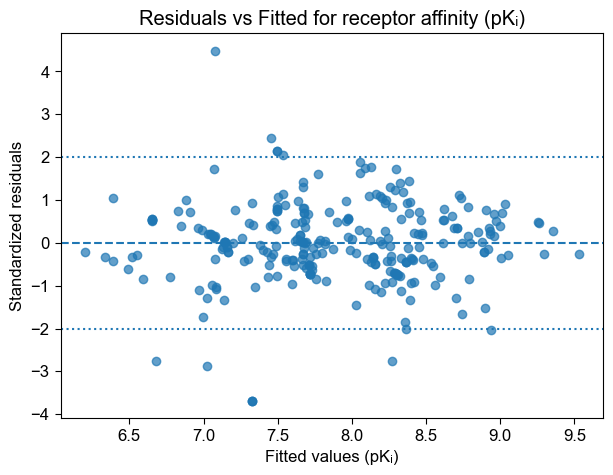

Residual summary:
count    2.750000e+02
mean     3.875688e-16
std      9.461272e-01
min     -3.685931e+00
25%     -4.448933e-01
50%      8.955261e-03
75%      5.398702e-01
max      4.484074e+00
dtype: float64


In [87]:
# ============================================================
# DIAGNOSTIC 1: Residuals vs Fitted
# for one representative imputed dataset (imputation 1)
# ============================================================



# --- recreate one imputed dataset
df_imp_1 = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
)

# --- fit model on this imputed dataset
res_imp_1 = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# --- fitted values and residuals
fitted_1 = res_imp_1.fittedvalues
residuals_1 = res_imp_1.resid

# standardized residuals
resid_sd_1 = np.sqrt(res_imp_1.scale)
std_residuals_1 = residuals_1 / resid_sd_1

# --- plot
plt.figure(figsize=(7,5))
plt.scatter(fitted_1, std_residuals_1, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle=":")
plt.axhline(-2, linestyle=":")
plt.xlabel("Fitted values (pKᵢ)")
plt.ylabel("Standardized residuals")
plt.title("Residuals vs Fitted for receptor affinity (pKᵢ)") #(MI model, imputation 1)
plt.savefig("residuals_vs_fitted_ki.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual summary:")
print(pd.Series(std_residuals_1).describe())

### Resdiduals  vs Substance

Residual summary by substance:
substance     substance_label  n  mean_std_residual  sd_std_residual  min_std_residual  max_std_residual  median_std_residual
  6918505       JWH-133 (n=6)  6          -0.144912         0.632556         -0.490928          1.131085            -0.390074
   638026        Δ⁸-THC (n=9)  9          -0.022047         0.626099         -1.318549          0.981038            -0.086036
    16078       Δ⁹-THC (n=28) 28           0.002394         0.639603         -1.255822          1.414666            -0.065251
   104850   Rimonabant (n=79) 79           0.007660         0.948337         -2.839270          1.969736            -0.062909
  5281969 CHEMBL381689 (n=28) 28          -0.012355         0.717763         -1.670562          1.724276             0.008373
 44208932    Anandamide (n=7)  7          -0.053659         2.214139         -2.818261          4.398138             0.020794
  5311501  WIN55,212-2 (n=63) 63           0.001712         1.149864         -3.604618 

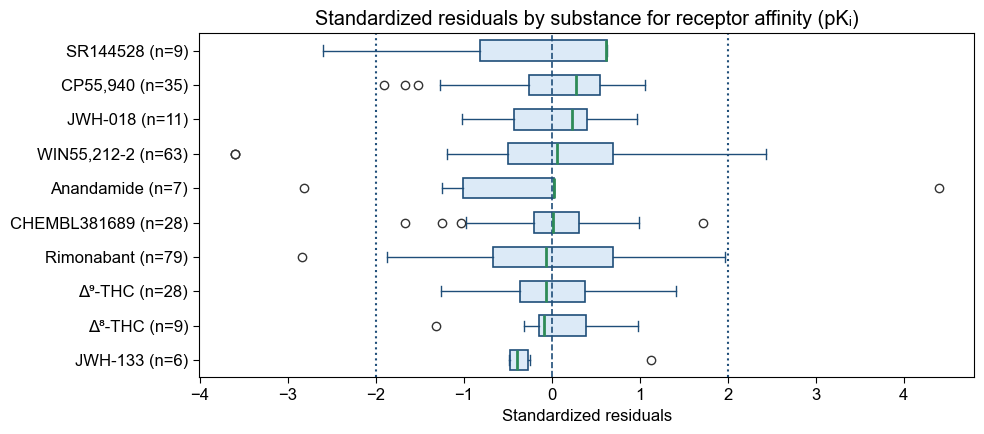

In [88]:
# ============================================================
# DIAGNOSTIC A: Standardized residuals by substance
# prettier version with substance names instead of pubchem_cid
# for one representative imputed dataset (imputation 1)
# ============================================================


# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
#    Bitte bei Bedarf anpassen
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "10382701": "JWH-018",
    "104850": "Rimonabant",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "638026": "Δ⁸-THC",
    "5281969": "CHEMBL381689",
    "44208932": "Anandamide",
    "3081355": "SR144528",
    "6918505": "JWH-133",
}

# ------------------------------------------------------------
# 2) recreate one imputed dataset
# ------------------------------------------------------------
df_imp_1 = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
).copy()

# ------------------------------------------------------------
# 3) fit model
# ------------------------------------------------------------
res_imp_1 = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# ------------------------------------------------------------
# 4) residuals
# ------------------------------------------------------------
residuals_1 = res_imp_1.resid
std_residuals_1 = residuals_1 / np.sqrt(res_imp_1.scale)

# ------------------------------------------------------------
# 5) build diagnostic dataframe
# ------------------------------------------------------------
diag_substance_df = pd.DataFrame({
    "substance": df_imp_1[GROUP].astype(str).values,
    "residual": residuals_1,
    "std_residual": std_residuals_1
})

# n pro Substanz
n_df = (
    diag_substance_df.groupby("substance", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

diag_substance_df = diag_substance_df.merge(n_df, on="substance", how="left")

# schöne Labels mit Namen + n
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

diag_substance_df["substance_label"] = diag_substance_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# Reihenfolge: nach Median der standardisierten Residuen sortieren
order_df = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(median_std_residual=("std_residual", "median"))
    .sort_values("median_std_residual")
)

ordered_labels = order_df["substance_label"].tolist()

# summary table
substance_summary = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
    .sort_values("median_std_residual")
)

print("Residual summary by substance:")
print(substance_summary.to_string(index=False))

# ------------------------------------------------------------
# 6) plot settings
# ------------------------------------------------------------
# ruhigere Farben:
box_face = "#DCEAF7"       # helles blau
box_edge = "#1F4E79"       # dunkles blau
median_color = "#2E8B57"   # gedämpftes grün
whisker_color = "#1F4E79"
cap_color = "#1F4E79"
flier_edge = "#333333"

# Daten in gewünschter Reihenfolge
data_to_plot = [
    diag_substance_df.loc[diag_substance_df["substance_label"] == lab, "std_residual"].values
    for lab in ordered_labels
]

# ------------------------------------------------------------
# 7) horizontal boxplot
# ------------------------------------------------------------
#fig, ax = plt.subplots(figsize=(10, max(4.5, 0.6 * len(ordered_labels))))
fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    labels=ordered_labels,
    widths=0.6,
    whis=1.5
)

# Farben anpassen
for box in bp["boxes"]:
    box.set(facecolor=box_face, edgecolor=box_edge, linewidth=1.2)

for whisker in bp["whiskers"]:
    whisker.set(color=whisker_color, linewidth=1.0)

for cap in bp["caps"]:
    cap.set(color=cap_color, linewidth=1.0)

for median in bp["medians"]:
    median.set(color=median_color, linewidth=2.0)

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor=flier_edge,
        markersize=6,
        linestyle="none"
    )

# Referenzlinien
ax.axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
ax.axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
ax.axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)

# Achsen / Titel
ax.set_title("Standardized residuals by substance for receptor affinity (pKᵢ)") #(MI model, imputation 1)
ax.set_xlabel("Standardized residuals")
ax.set_ylabel("")

# Kein Grid im Hintergrund
ax.grid(False)
plt.savefig("standarized_residuals_by_substance_pki.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Random intercept per substance

Random intercepts by substance:
substance  n  random_intercept               label
  6918505  6         -1.185784       JWH-133 (n=6)
  3081355  9         -0.876287      SR144528 (n=9)
 44208932  7         -0.500756    Anandamide (n=7)
  5281969 28         -0.497442 CHEMBL381689 (n=28)
   638026  9         -0.247849     Δ$^8$-THC (n=9)
    16078 28          0.087851    Δ$^9$-THC (n=28)
  5311501 63          0.136495  WIN55,212-2 (n=63)
   104850 79          0.809627   Rimonabant (n=79)
 10382701 11          0.937245      JWH-018 (n=11)
   104895 35          1.336901     CP55,940 (n=35)


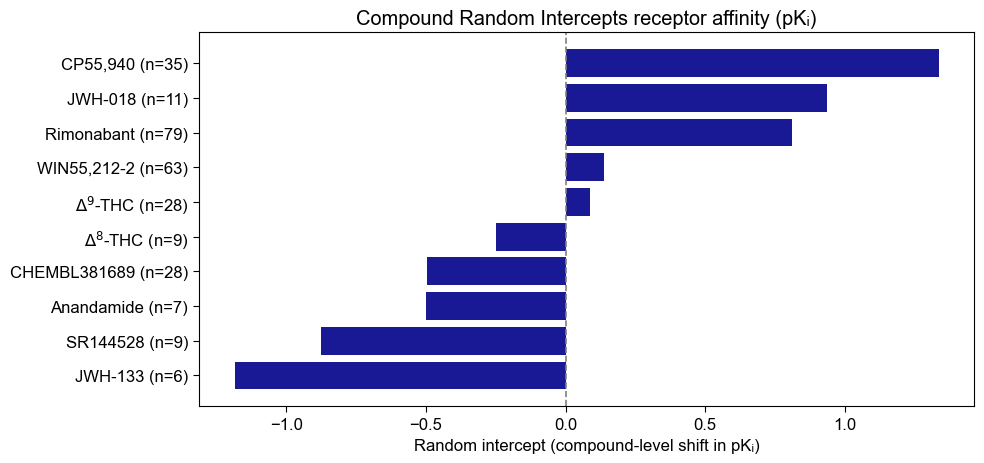

In [89]:
# ============================================================
# DIAGNOSTIC B: Random intercepts by substance
# styled like the older compound random-intercept figure
# for one representative imputed dataset (imputation 1)
# ============================================================

# ------------------------------------------------------------
# 1) optional: mapping pubchem_cid -> nicer substance name
#    If a cid is not in the map, the cid itself will be shown.
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "10382701": "JWH-018",
    "104850": "Rimonabant",
    "5311501": "WIN55,212-2",
    "16078": "Δ$^9$-THC",
    "638026": "Δ$^8$-THC",
    "5281969": "CHEMBL381689",
    "44208932": "Anandamide",
    "3081355": "SR144528",
    "6918505": "JWH-133",
}
# ------------------------------------------------------------
# 2) recreate one imputed dataset
# ------------------------------------------------------------
df_imp_1 = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
).copy()

# ------------------------------------------------------------
# 3) fit model
# ------------------------------------------------------------
res_imp_1 = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# ------------------------------------------------------------
# 4) extract random intercepts
# ------------------------------------------------------------
re_dict = res_imp_1.random_effects

random_intercepts = []
for substance, effect in re_dict.items():
    if hasattr(effect, "iloc"):
        val = float(effect.iloc[0])
    elif isinstance(effect, (list, tuple, np.ndarray)):
        val = float(effect[0])
    else:
        val = float(effect)

    random_intercepts.append({
        "substance": str(substance),
        "random_intercept": val
    })

re_df = pd.DataFrame(random_intercepts)

# ------------------------------------------------------------
# 5) add n per substance
# ------------------------------------------------------------
n_df = (
    df_imp_1.groupby(GROUP, as_index=False)
    .size()
    .rename(columns={GROUP: "substance", "size": "n"})
)
n_df["substance"] = n_df["substance"].astype(str)

re_df = re_df.merge(n_df, on="substance", how="left")

# ------------------------------------------------------------
# 6) build pretty y-axis labels
# ------------------------------------------------------------
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

re_df["label"] = re_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# sort from lowest to highest random intercept
re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

print("Random intercepts by substance:")
print(re_df[["substance", "n", "random_intercept", "label"]].to_string(index=False))

# ------------------------------------------------------------
# 7) plot: horizontal bars, no grid, dark blue
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.8))

plt.barh(
    re_df["label"],
    re_df["random_intercept"],
    color="darkblue",
    alpha=0.9
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1.2)

# no grid in background
plt.grid(False)

plt.xlabel("Random intercept (compound-level shift in pKᵢ)")
plt.ylabel("")
plt.title("Compound Random Intercepts receptor affinity (pKᵢ)")

plt.tight_layout()
plt.savefig("compound_random_intercept_pki.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 600x600 with 0 Axes>

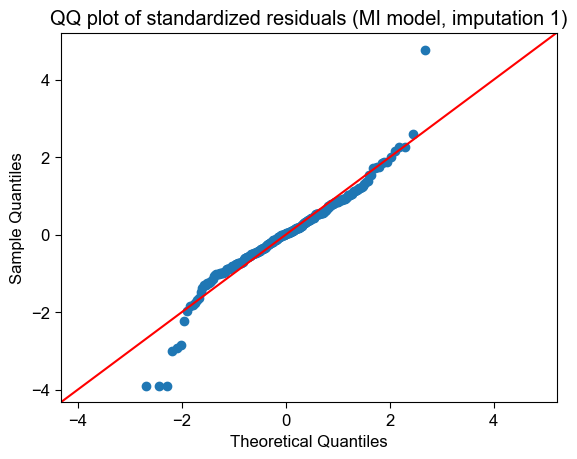

In [90]:
# ============================================================
# DIAGNOSTIC 2: QQ-Plot of residuals
# for one representative imputed dataset (imputation 1)
# ============================================================


# --- if not already available from previous block, recreate
try:
    res_imp_1
except NameError:
    df_imp_1 = create_one_imputed_dataset(
        base_df=base_df,
        imp_df=imp_df,
        imputer=imputer,
        cats=CATS,
        nums=NUMS,
        cat_dummy_cols=cat_dummy_cols,
        y_col=Y,
        group_col=GROUP
    )

    res_imp_1 = fit_mixedlm_safe(
        formula=formula_fixed,
        data=df_imp_1,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=USE_REML_FINAL
    )

residuals_1 = res_imp_1.resid
std_residuals_1 = residuals_1 / np.sqrt(res_imp_1.scale)

# --- QQ plot
plt.figure(figsize=(6, 6))
sm.qqplot(std_residuals_1, line="45", fit=True)
plt.title("QQ plot of standardized residuals (MI model, imputation 1)")
plt.show()

In [91]:
# ============================================================
# DIAGNOSTIC 3: Leave-one-substance-out sensitivity analysis
# for the MI model
# ============================================================

# ------------------------------------------------------------
# helper: pool fixed effects from a list of fitted models
# ------------------------------------------------------------
def pool_fixed_effects_from_results(results_list):
    fe_params_list = []
    fe_cov_list = []

    for res in results_list:
        fe_names = res.fe_params.index.tolist()
        fe_params = res.fe_params.copy()
        fe_cov = res.cov_params().loc[fe_names, fe_names].copy()

        fe_params_list.append(fe_params)
        fe_cov_list.append(fe_cov)

    return pool_fixed_effects(fe_params_list, fe_cov_list)


# ------------------------------------------------------------
# 1) recreate MI datasets and fit baseline MI models
# ------------------------------------------------------------
mi_datasets = []
mi_results_full = []

for m_idx in range(MI_M):
    df_imp_m = create_one_imputed_dataset(
        base_df=base_df,
        imp_df=imp_df,
        imputer=imputer,
        cats=CATS,
        nums=NUMS,
        cat_dummy_cols=cat_dummy_cols,
        y_col=Y,
        group_col=GROUP
    )
    mi_datasets.append(df_imp_m)

    res_full_m = fit_mixedlm_safe(
        formula=formula_fixed,
        data=df_imp_m,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=USE_REML_FINAL
    )
    mi_results_full.append(res_full_m)

# pooled baseline estimates
pooled_full = pool_fixed_effects_from_results(mi_results_full).copy()
pooled_full = pooled_full.rename(columns={"estimate": "estimate_full"})
pooled_full = pooled_full[["term", "estimate_full"]]

print("Baseline pooled MI model ready.")
print(pooled_full.to_string(index=False))


# ------------------------------------------------------------
# 2) leave-one-substance-out
# ------------------------------------------------------------
substances = sorted(pd.Series(mi_datasets[0][GROUP].astype(str).unique()).tolist())

loo_rows = []
failed_substances = []

for substance in substances:
    loo_results = []

    for df_imp_m in mi_datasets:
        df_loo = df_imp_m[df_imp_m[GROUP].astype(str) != str(substance)].copy()

        # must still have at least 2 groups
        n_groups = df_loo[GROUP].astype(str).nunique()
        if n_groups < 2:
            continue

        try:
            res_loo = fit_mixedlm_safe(
                formula=formula_fixed,
                data=df_loo,
                group_col=GROUP,
                categorical_cols=CATS,
                reml=USE_REML_FINAL
            )
            loo_results.append(res_loo)

        except Exception as e:
            failed_substances.append({
                "left_out_substance": substance,
                "error": str(e)
            })

    # if no successful fits for this substance, skip
    if len(loo_results) == 0:
        continue

    pooled_loo = pool_fixed_effects_from_results(loo_results).copy()
    pooled_loo = pooled_loo.rename(columns={"estimate": "estimate_loo"})
    pooled_loo = pooled_loo[["term", "estimate_loo"]]

    merged = pooled_full.merge(pooled_loo, on="term", how="inner")
    merged["left_out_substance"] = substance
    merged["abs_change"] = (merged["estimate_loo"] - merged["estimate_full"]).abs()

    merged["rel_change_pct"] = np.where(
        merged["estimate_full"].abs() > 1e-8,
        100 * merged["abs_change"] / merged["estimate_full"].abs(),
        np.nan
    )

    loo_rows.append(merged)

if len(loo_rows) == 0:
    raise RuntimeError("No leave-one-substance-out models could be fitted.")

loo_df = pd.concat(loo_rows, ignore_index=True)


# ------------------------------------------------------------
# 3) summarize influence per coefficient
# ------------------------------------------------------------
summary_rows = []

for term, subdf in loo_df.groupby("term"):
    idx_max = subdf["abs_change"].idxmax()

    summary_rows.append({
        "term": term,
        "max_abs_change": subdf["abs_change"].max(),
        "median_abs_change": subdf["abs_change"].median(),
        "worst_case_substance": loo_df.loc[idx_max, "left_out_substance"],
        "baseline_estimate": loo_df.loc[idx_max, "estimate_full"]
    })

loo_summary = pd.DataFrame(summary_rows).sort_values(
    "max_abs_change", ascending=False
)

print("\nLeave-one-substance-out summary:")
print(loo_summary.to_string(index=False))


# ------------------------------------------------------------
# 4) detailed results for selected terms
# ------------------------------------------------------------
key_terms = [
    "Intercept",
    "C(cell_cleaned, Treatment(reference='hek'))[T.cho]",
    "C(cell_cleaned, Treatment(reference='hek'))[T.chem-1]",
    "incubation_time",
    "temp",
    "log10_concentration_radioligand_nM"
]

print("\nDetailed leave-one-substance-out results for selected terms:")
detail_df = loo_df[loo_df["term"].isin(key_terms)].copy()
detail_df = detail_df.sort_values(["term", "abs_change"], ascending=[True, False])
print(detail_df.to_string(index=False))


# ------------------------------------------------------------
# 5) optional: show failed leave-one-out fits
# ------------------------------------------------------------
if len(failed_substances) > 0:
    failed_df = pd.DataFrame(failed_substances).drop_duplicates()
    print("\nLeave-one-substance-out fits with errors:")
    print(failed_df.to_string(index=False))
else:
    print("\nAll leave-one-substance-out fits completed without recorded errors.")

Baseline pooled MI model ready.
                                                                          term  estimate_full
                                                                     Intercept       7.443037
                    C(receptor_species, Treatment(reference='human'))[T.mouse]       0.056957
                      C(receptor_species, Treatment(reference='human'))[T.rat]       0.023748
       C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.CELT-335]      -0.490304
    C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[125I]AM251]       0.235771
  C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[125I]SD-7015]       0.391025
   C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[131I]AM2233]       0.954200
     C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[35S]GTPγS]       0.284543
     C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[3H]HU-243]      -0.116411
    C(reference_substance, T

### Observation-level influence diagnostics

Top observations by absolute standardized residual:
 original_row_id pubchem_cid  value_pKi   fitted  residual  std_residual
              11    44208932   9.397940 7.136155  2.261785      4.293561
             264     5311501   5.419988 7.315638 -1.895650     -3.598526
             263     5311501   5.419988 7.315638 -1.895650     -3.598526
             262     5311501   5.420216 7.315638 -1.895422     -3.598092
             204      104850   6.844664 8.376649 -1.531985     -2.908177
             216    44208932   5.539102 6.947006 -1.407903     -2.672632
             217     3081355   5.249646 6.637957 -1.388312     -2.635441
              10      104850   9.397940 8.107199  1.290741      2.450222
              43     5311501   8.721246 7.457341  1.263906      2.399280
             166      104850   7.327902 8.486415 -1.158513     -2.199213
              48     5311501   8.602060 7.517165  1.084895      2.059463
              49     5311501   8.602060 7.517165  1.084895      2.059463

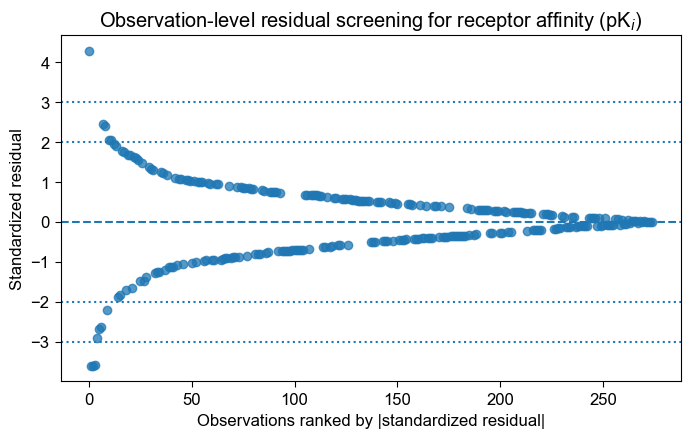


Observation-level influence summary (top suspicious observations):
 original_row_id substance  std_residual  max_abs_change  median_abs_change
              11  44208932      4.293561        0.081416           0.016287
             217   3081355     -2.635441        0.078529           0.008453
             263   5311501     -3.598526        0.061364           0.009332
             264   5311501     -3.598526        0.061364           0.009332
             262   5311501     -3.598092        0.061357           0.009331
             204    104850     -2.908177        0.059857           0.008896
             216  44208932     -2.672632        0.044396           0.011081
             166    104850     -2.199213        0.034580           0.005740
             230    104850      1.907807        0.028753           0.003922
              43   5311501      2.399280        0.023244           0.004292
              47   5311501      1.945898        0.021908           0.002920
              48   5

In [92]:
# ============================================================
# DIAGNOSTIC C: Observation-level influence diagnostics
# for one representative imputed dataset (imputation 1)
# ------------------------------------------------------------
# What this does:
# 1) fits the MI model on imputation 1
# 2) computes fitted values, residuals, standardized residuals
# 3) flags potentially influential observations via large residuals
# 4) re-fits the model leaving out the top suspicious observations
#    one at a time, and measures coefficient changes
# ============================================================


# ------------------------------------------------------------
# 1) build one imputed dataset and fit model
# ------------------------------------------------------------
df_imp_1 = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
).copy()

# keep original row id for traceability
df_imp_1 = df_imp_1.reset_index(drop=False).rename(columns={"index": "original_row_id"})

res_imp_1 = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# ------------------------------------------------------------
# 2) fitted values and residuals
# ------------------------------------------------------------
diag_obs_df = df_imp_1.copy()
diag_obs_df["fitted"] = res_imp_1.fittedvalues
diag_obs_df["residual"] = res_imp_1.resid
diag_obs_df["std_residual"] = diag_obs_df["residual"] / np.sqrt(res_imp_1.scale)
diag_obs_df["abs_std_residual"] = diag_obs_df["std_residual"].abs()

# sort by most extreme residuals
diag_obs_df = diag_obs_df.sort_values("abs_std_residual", ascending=False).reset_index(drop=True)

print("Top observations by absolute standardized residual:")
cols_to_show = [
    "original_row_id", GROUP, Y, "fitted", "residual", "std_residual"
]
print(diag_obs_df[cols_to_show].head(15).to_string(index=False))

# ------------------------------------------------------------
# 3) quick plot: standardized residuals by observation rank
# ------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.scatter(range(len(diag_obs_df)), diag_obs_df["std_residual"], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle=":")
plt.axhline(-2, linestyle=":")
plt.axhline(3, linestyle=":")
plt.axhline(-3, linestyle=":")
plt.xlabel("Observations ranked by |standardized residual|")
plt.ylabel("Standardized residual")
plt.title("Observation-level residual screening for receptor affinity (pK$_i$)") #(MI model, imputation 1)
plt.savefig("observations_ranked_pKi.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4) define baseline coefficients
# ------------------------------------------------------------
baseline_params = res_imp_1.fe_params.copy()

# ------------------------------------------------------------
# 5) leave-one-observation-out for top suspicious observations
# ------------------------------------------------------------
# We only do this for the top N observations to keep runtime manageable.
TOP_N = 15

top_obs = diag_obs_df.head(TOP_N).copy()

loo_obs_rows = []
failed_obs = []

for _, row in top_obs.iterrows():
    row_id = row["original_row_id"]

    df_minus_one = df_imp_1[df_imp_1["original_row_id"] != row_id].copy()

    try:
        res_minus_one = fit_mixedlm_safe(
            formula=formula_fixed,
            data=df_minus_one,
            group_col=GROUP,
            categorical_cols=CATS,
            reml=USE_REML_FINAL
        )

        params_minus_one = res_minus_one.fe_params.copy()

        # align coefficients
        merged = pd.DataFrame({
            "term": baseline_params.index,
            "estimate_full": baseline_params.reindex(baseline_params.index).values,
            "estimate_minus_one": params_minus_one.reindex(baseline_params.index).values
        })

        merged["original_row_id"] = row_id
        merged["substance"] = str(row[GROUP])
        merged["std_residual"] = float(row["std_residual"])
        merged["abs_change"] = (merged["estimate_minus_one"] - merged["estimate_full"]).abs()
        merged["rel_change_pct"] = np.where(
            merged["estimate_full"].abs() > 1e-8,
            100 * merged["abs_change"] / merged["estimate_full"].abs(),
            np.nan
        )

        loo_obs_rows.append(merged)

    except Exception as e:
        failed_obs.append({
            "original_row_id": row_id,
            "substance": str(row[GROUP]),
            "std_residual": float(row["std_residual"]),
            "error": str(e)
        })

if len(loo_obs_rows) == 0:
    raise RuntimeError("All leave-one-observation-out fits failed for the selected observations.")

loo_obs_df = pd.concat(loo_obs_rows, ignore_index=True)

# ------------------------------------------------------------
# 6) summarize which observations have strongest impact
# ------------------------------------------------------------
obs_influence_summary = (
    loo_obs_df.groupby(["original_row_id", "substance", "std_residual"], as_index=False)
    .agg(
        max_abs_change=("abs_change", "max"),
        median_abs_change=("abs_change", "median")
    )
    .sort_values("max_abs_change", ascending=False)
)

print("\nObservation-level influence summary (top suspicious observations):")
print(obs_influence_summary.to_string(index=False))

# ------------------------------------------------------------
# 7) summarize which coefficients are most sensitive
# ------------------------------------------------------------
coef_sensitivity_summary = (
    loo_obs_df.groupby("term", as_index=False)
    .agg(
        max_abs_change=("abs_change", "max"),
        median_abs_change=("abs_change", "median")
    )
    .sort_values("max_abs_change", ascending=False)
)

print("\nCoefficient sensitivity to deleting one suspicious observation:")
print(coef_sensitivity_summary.to_string(index=False))

# ------------------------------------------------------------
# 8) detailed output for selected key terms
# ------------------------------------------------------------
key_terms = [
    "Intercept",
    "C(cell_cleaned, Treatment(reference='hek'))[T.cho]",
    "C(cell_cleaned, Treatment(reference='hek'))[T.chem-1]",
    "incubation_time",
    "temp",
    "log10_concentration_radioligand_nM"
]

detail_obs = loo_obs_df[loo_obs_df["term"].isin(key_terms)].copy()
detail_obs = detail_obs.sort_values(["term", "abs_change"], ascending=[True, False])

print("\nDetailed observation-level influence results for selected terms:")
print(detail_obs.to_string(index=False))

# ------------------------------------------------------------
# 9) optional: failed fits
# ------------------------------------------------------------
if len(failed_obs) > 0:
    failed_obs_df = pd.DataFrame(failed_obs)
    print("\nLeave-one-observation-out fits with errors:")
    print(failed_obs_df.to_string(index=False))
else:
    print("\nAll leave-one-observation-out fits completed without recorded errors.")

## Figures main manuscript

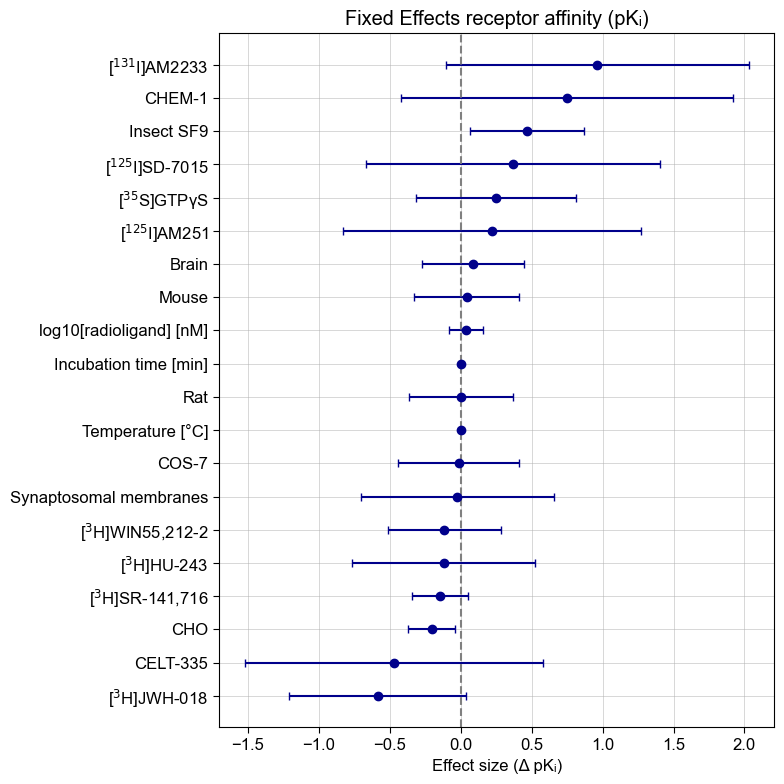

In [93]:
# ============================================================
# Fixed-effects plot for MULTIPLE IMPUTATION pooled results
# uses: pooled_fixed
# expected columns in pooled_fixed:
#   term, estimate, ci_low_95, ci_high_95
# ============================================================


# ------------------------------------------------------------
# 1) helper: raw parameter name -> pretty label
# ------------------------------------------------------------
def pretty_param_mi(name: str) -> str:
    if name == "Intercept":
        return name

    # numeric predictors
    num_map = {
        "incubation_time": "Incubation time [min]",
        "temp": "Temperature [°C]",
        "log10_concentration_radioligand_nM": "log10[radioligand] [nM]",
    }
    if name in num_map:
        return num_map[name]

    # receptor species
    m_species = re.match(
        r"C\(receptor_species, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_species:
        lvl = m_species.group(1)
        lvl_map = {
            "mouse": "Mouse",
            "rat": "Rat",
            "human": "Human",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # reference substance
    m_ref = re.match(
        r"C\(reference_substance, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_ref:
        lvl = m_ref.group(1)
        lvl_map = {
            "CELT-335": "CELT-335",
            "[125I]AM251": "[$^{125}$I]AM251",
            "[125I]SD-7015": "[$^{125}$I]SD-7015",
            "[131I]AM2233": "[$^{131}$I]AM2233",
            "[35S]GTPγS": "[$^{35}$S]GTPγS",
            "[3H]HU-243": "[$^3$H]HU-243",
            "[3H]JWH-018": "[$^3$H]JWH-018",
            "[3H]SR-141,716": "[$^3$H]SR-141,716",
            "[3H]WIN-55212-2": "[$^3$H]WIN55,212-2",
            "[3H]CP-55940": "[$^3$H]CP-55940",
        }
        return lvl_map.get(lvl, lvl)

    # cell membrane
    m_cell = re.match(
        r"C\(cell_cleaned, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_cell:
        lvl = m_cell.group(1)
        lvl_map = {
            "brain": "Brain",
            "chem-1": "CHEM-1",
            "cho": "CHO",
            "cos": "COS-7",
            "insect SF9": "Insect SF9",
            "synaptosomal membranes": "Synaptosomal membranes",
            "hek": "HEK",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # fallback
    return name.replace("_", " ")


# ------------------------------------------------------------
# 2) plotting function for pooled MI results
# ------------------------------------------------------------
def plot_fixed_effects_mi(
    pooled_df,
    title="Fixed Effects receptor affinity (pKᵢ)",
    x_label="Effect size (Δ pKᵢ)",
    outfile="Fixed_effects_pKi_MI.tiff",
    drop_intercept=True
):
    # keep only required columns
    plot_df = pooled_df[["term", "estimate", "ci_low_95", "ci_high_95"]].copy()

    if drop_intercept:
        plot_df = plot_df[plot_df["term"] != "Intercept"].copy()

    # pretty labels
    plot_df["label"] = plot_df["term"].apply(pretty_param_mi)

    # sort by estimate
    plot_df = plot_df.sort_values("estimate").reset_index(drop=True)

    # plot
    #plt.figure(figsize=(8, len(plot_df) * 0.5 + 1))
    plt.figure(figsize=(8, 8))
    plt.errorbar(
        plot_df["estimate"],
        plot_df["label"],
        xerr=[
            plot_df["estimate"] - plot_df["ci_low_95"],
            plot_df["ci_high_95"] - plot_df["estimate"]
        ],
        fmt="o",
        capsize=3,
        color="darkblue",
        ecolor="darkblue"
    )
    plt.axvline(0, color="grey", linestyle="--")
    plt.title(title)
    plt.xlabel(x_label)
    plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    return plot_df


# ------------------------------------------------------------
# 3) call
# ------------------------------------------------------------
plot_df_mi = plot_fixed_effects_mi(
    pooled_df=pooled_fixed,
    title="Fixed Effects receptor affinity (pKᵢ)",
    x_label="Effect size (Δ pKᵢ)",
    outfile="Fixed_effects_pKi_MI.png"
)

### Observed vs Predicted pKᵢ

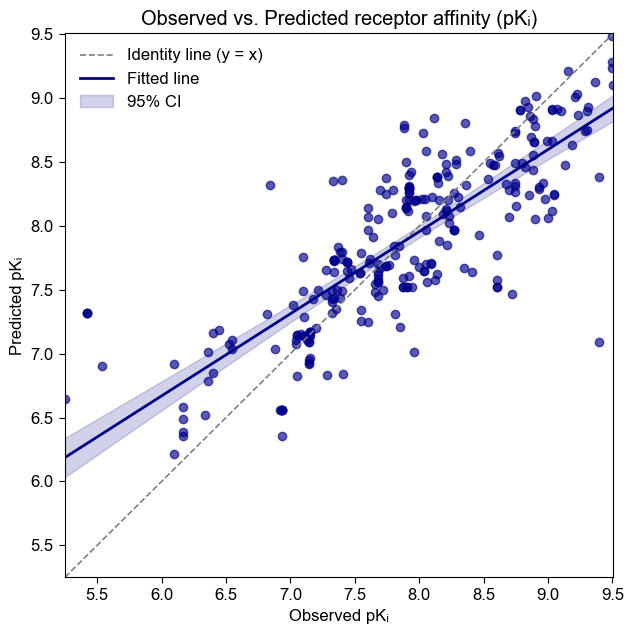

Correlation observed vs predicted: 0.810
RMSE: 0.490
                            OLS Regression Results                            
Dep. Variable:              predicted   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     519.3
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           4.09e-65
Time:                        17:06:05   Log-Likelihood:                -130.59
No. Observations:                 275   AIC:                             265.2
Df Residuals:                     273   BIC:                             272.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [94]:
# ============================================================
# Observed vs Predicted pKᵢ for current MI-LMM
# - based on one representative imputed dataset (imputation 1)
# - x = observed pKᵢ
# - y = predicted pKᵢ
# - includes:
#     1) identity line (y = x)
#     2) fitted regression line
#     3) 95% confidence interval around regression line
# ============================================================

# ------------------------------------------------------------
# 1) recreate one imputed dataset
# ------------------------------------------------------------
df_imp_1 = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
).copy()

# ------------------------------------------------------------
# 2) fit current LMM on this imputed dataset
# ------------------------------------------------------------
res_imp_1 = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# ------------------------------------------------------------
# 3) extract observed and predicted values
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    "observed": df_imp_1[Y].astype(float).values,
    "predicted": res_imp_1.fittedvalues.astype(float)
}).dropna().copy()

# ------------------------------------------------------------
# 4) regression line + 95% CI
#    predicted ~ observed
# ------------------------------------------------------------
X = sm.add_constant(plot_df["observed"])
ols_line = sm.OLS(plot_df["predicted"], X).fit()

x_grid = np.linspace(plot_df["observed"].min(), plot_df["observed"].max(), 200)
X_grid = sm.add_constant(x_grid)

pred_frame = ols_line.get_prediction(X_grid).summary_frame(alpha=0.05)

# ------------------------------------------------------------
# 5) plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6.5))

# scatter
ax.scatter(
    plot_df["observed"],
    plot_df["predicted"],
    alpha=0.65,
    color="darkblue"
)

# identity line y = x
xy_min = min(plot_df["observed"].min(), plot_df["predicted"].min())
xy_max = max(plot_df["observed"].max(), plot_df["predicted"].max())

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="grey",
    linewidth=1.2,
    label="Identity line (y = x)"
)

# regression line
ax.plot(
    x_grid,
    pred_frame["mean"],
    color="darkblue",
    linewidth=2,
    label="Fitted line"
)

# confidence interval around regression line
ax.fill_between(
    x_grid,
    pred_frame["mean_ci_lower"].values,
    pred_frame["mean_ci_upper"].values,
    color="darkblue",
    alpha=0.18,
    label="95% CI"
)

# labels and title
ax.set_xlabel("Observed pKᵢ")
ax.set_ylabel("Predicted pKᵢ")
ax.set_title("Observed vs. Predicted receptor affinity (pKᵢ)")

# equal-ish limits so identity line is meaningful
ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("Observed_vs_Predicted_pKi_MI_imputation1.tiff", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6) optional numeric summary
# ------------------------------------------------------------
corr = np.corrcoef(plot_df["observed"], plot_df["predicted"])[0, 1]
rmse = np.sqrt(np.mean((plot_df["observed"] - plot_df["predicted"])**2))

print(f"Correlation observed vs predicted: {corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(ols_line.summary())

# Summary of dataset

In [95]:
data.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,2.750000e+02,275.000000,275.000000,0.0,0.0,209.000000,77.000000,230.000000,195.000000
mean,3.613026e+06,123.400003,7.875835,NaN,NaN,1.521383,11.526870,80.086957,30.605128
std,7.202261e+06,553.721511,0.836073,NaN,NaN,6.255058,78.935863,35.540017,12.822860
min,1.607800e+04,0.310000,5.249646,NaN,NaN,0.000028,0.017000,15.000000,4.000000
25%,1.048500e+05,3.150000,7.339139,NaN,NaN,0.270000,0.180000,60.000000,30.000000
50%,1.048950e+05,12.500000,7.903090,NaN,NaN,0.500000,0.690000,60.000000,30.000000
75%,5.311501e+06,45.800000,8.503062,NaN,NaN,1.000000,1.130000,90.000000,30.000000
max,4.420893e+07,5628.000000,9.508638,NaN,NaN,84.000000,690.000000,360.000000,200.000000


In [96]:
print(data["pubchem_cid"].value_counts())

pubchem_cid
104850      79
5311501     63
104895      35
16078       28
5281969     28
10382701    11
638026       9
3081355      9
44208932     7
6918505      6
Name: count, dtype: int64


In [97]:

print(data["reference_substance"].value_counts())
print(data["cell_cleaned"].value_counts())
print(data["receptor_species"].value_counts())


reference_substance
[3H]CP-55940       211
[3H]SR-141,716      39
[3H]WIN-55212-2      8
[3H]HU-243           5
[35S]GTPγS           4
[3H]JWH-018          3
[125I]AM251          1
[125I]SD-7015        1
[131I]AM2233         1
CELT-335             1
Name: count, dtype: int64
cell_cleaned
hek                       104
brain                      70
cho                        70
insect SF9                  8
cos                         7
synaptosomal membranes      3
chem-1                      1
Name: count, dtype: int64
receptor_species
human    193
rat       59
mouse     21
Name: count, dtype: int64


## Rimonabant

In [98]:
Rimonabant_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,79.0,79.000000,79.000000,0.0,0.0,57.000000,27.000000,66.000000,53.000000
mean,104850.0,10.202637,8.301322,NaN,NaN,1.551053,1.851370,72.045455,29.471698
std,0.0,17.714554,0.534343,NaN,NaN,3.666484,2.922002,25.404077,2.984600
min,104850.0,0.310000,6.844664,NaN,NaN,0.040000,0.017000,45.000000,20.000000
25%,104850.0,1.800000,7.920819,NaN,NaN,0.300000,0.180000,60.000000,30.000000
50%,104850.0,6.180000,8.209012,NaN,NaN,0.700000,0.800000,60.000000,30.000000
75%,104850.0,12.000000,8.744727,NaN,NaN,1.000000,1.185000,90.000000,30.000000
max,104850.0,143.000000,9.508638,NaN,NaN,20.000000,10.100000,180.000000,37.000000


In [99]:
print(Rimonabant_df["reference_substance"].value_counts())
print(Rimonabant_df["cell_cleaned"].value_counts())
print(Rimonabant_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       49
[3H]SR-141,716     22
[35S]GTPγS          3
[3H]WIN-55212-2     2
[125I]AM251         1
[125I]SD-7015       1
[3H]JWH-018         1
Name: count, dtype: int64
cell_cleaned
hek           33
cho           25
brain         16
insect SF9     2
Name: count, dtype: int64
receptor_species
human    59
rat      15
mouse     4
Name: count, dtype: int64


## WIN-55212

In [100]:
WIN_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,63.0,63.000000,63.000000,0.0,0.0,47.000000,16.00000,51.000000,45.000000
mean,5311501.0,204.819683,7.670228,NaN,NaN,2.470638,1.57625,80.000000,29.555556
std,0.0,811.034692,0.654662,NaN,NaN,12.178502,2.73272,18.654758,1.438995
min,5311501.0,1.600000,5.419988,NaN,NaN,0.100000,0.11000,60.000000,25.000000
25%,5311501.0,11.150000,7.419616,NaN,NaN,0.400000,0.18000,60.000000,30.000000
50%,5311501.0,20.000000,7.698970,NaN,NaN,0.500000,0.76000,90.000000,30.000000
75%,5311501.0,38.100000,7.952764,NaN,NaN,0.800000,1.13000,90.000000,30.000000
max,5311501.0,3802.000000,8.795880,NaN,NaN,84.000000,10.10000,120.000000,30.000000


In [101]:
print(WIN_df["reference_substance"].value_counts())
print(WIN_df["cell_cleaned"].value_counts())
print(WIN_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       53
[3H]SR-141,716      5
[3H]WIN-55212-2     3
[131I]AM2233        1
Name: count, dtype: int64
cell_cleaned
hek           23
cho           20
brain         11
insect SF9     3
cos            2
Name: count, dtype: int64
receptor_species
human    50
rat       9
mouse     4
Name: count, dtype: int64


## CP-55,940

In [102]:
CP_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,35.0,35.000000,35.000000,0.0,0.0,27.000000,5.000000,28.000000,26.000000
mean,104895.0,2.492789,8.875352,NaN,NaN,1.035148,1.412000,85.714286,30.769231
std,0.0,3.415563,0.454574,NaN,NaN,0.852277,0.913165,26.726124,4.510501
min,104895.0,0.316200,7.886057,NaN,NaN,0.100000,0.390000,30.000000,21.000000
25%,104895.0,0.610000,8.781204,NaN,NaN,0.500000,0.720000,60.000000,30.000000
50%,104895.0,1.240000,8.906578,NaN,NaN,0.800000,1.240000,90.000000,30.000000
75%,104895.0,1.655000,9.214729,NaN,NaN,1.039500,2.310000,120.000000,35.250000
max,104895.0,13.000000,9.500038,NaN,NaN,3.500000,2.400000,120.000000,37.000000


In [103]:
print(CP_df["reference_substance"].value_counts())
print(CP_df["cell_cleaned"].value_counts())
print(CP_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       28
[3H]SR-141,716      5
[35S]GTPγS          1
[3H]WIN-55212-2     1
Name: count, dtype: int64
cell_cleaned
cho           13
hek           11
brain          7
insect SF9     3
Name: count, dtype: int64
receptor_species
human    28
rat       5
mouse     2
Name: count, dtype: int64


## Anandamide

In [104]:
Anandamide_2_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,28.0,28.000000,28.000000,0.0,0.0,23.000000,11.000000,24.000000,17.000000
mean,5281969.0,132.364286,7.048884,NaN,NaN,1.579132,8.140909,66.250000,40.000000
std,0.0,159.828974,0.364278,NaN,NaN,4.265662,25.161698,12.445534,41.231056
min,5281969.0,11.000000,6.096910,NaN,NaN,0.000038,0.180000,60.000000,30.000000
25%,5281969.0,70.000000,7.045757,NaN,NaN,0.140000,0.180000,60.000000,30.000000
50%,5281969.0,73.000000,7.136718,NaN,NaN,0.500000,0.690000,60.000000,30.000000
75%,5281969.0,90.000000,7.154902,NaN,NaN,0.800000,0.825000,60.000000,30.000000
max,5281969.0,800.000000,7.958607,NaN,NaN,20.000000,84.000000,90.000000,200.000000


In [105]:
print(Anandamide_2_df["reference_substance"].value_counts())
print(Anandamide_2_df["cell_cleaned"].value_counts())
print(Anandamide_2_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       21
[3H]SR-141,716      4
[3H]HU-243          2
[3H]WIN-55212-2     1
Name: count, dtype: int64
cell_cleaned
brain                     15
hek                        7
cos                        4
cho                        1
synaptosomal membranes     1
Name: count, dtype: int64
receptor_species
rat      15
human    11
mouse     2
Name: count, dtype: int64


## 9-THC

In [106]:
THC9_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,28.0,28.000000,28.000000,0.0,0.0,21.000000,1.0,25.000000,21.000000
mean,16078.0,31.701071,7.644996,NaN,NaN,0.847620,6.5,100.200000,29.476190
std,0.0,22.200658,0.428874,NaN,NaN,1.224078,NaN,60.733022,7.124739
min,16078.0,1.050000,7.086186,NaN,NaN,0.000028,6.5,15.000000,4.000000
25%,16078.0,16.575000,7.356869,NaN,NaN,0.200000,6.5,90.000000,30.000000
50%,16078.0,26.500000,7.577995,NaN,NaN,0.500000,6.5,90.000000,30.000000
75%,16078.0,43.982500,7.780990,NaN,NaN,1.000000,6.5,120.000000,30.000000
max,16078.0,82.000000,8.978811,NaN,NaN,5.400000,6.5,360.000000,37.000000


In [107]:
print(THC9_df["reference_substance"].value_counts())
print(THC9_df["cell_cleaned"].value_counts())
print(THC9_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940      21
[3H]HU-243         3
[3H]SR-141,716     2
[3H]JWH-018        1
CELT-335           1
Name: count, dtype: int64
cell_cleaned
hek                       10
brain                      8
cho                        4
synaptosomal membranes     2
chem-1                     1
cos                        1
Name: count, dtype: int64
receptor_species
human    16
rat       8
mouse     4
Name: count, dtype: int64


## JWH-018

In [108]:
JWH018_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,11.0,11.000000,11.000000,0.0,0.0,9.000000,4.000000,10.000000,10.000000
mean,10382701.0,4.644091,8.417196,NaN,NaN,1.122222,176.020000,96.000000,27.800000
std,0.0,3.043681,0.284284,NaN,NaN,0.982061,342.662859,93.594872,9.283199
min,10382701.0,1.300000,8.020000,NaN,NaN,0.200000,1.080000,60.000000,4.000000
25%,10382701.0,2.625000,8.201309,NaN,NaN,0.500000,5.145000,60.000000,26.250000
50%,10382701.0,3.400000,8.468521,NaN,NaN,0.600000,6.500000,60.000000,30.000000
75%,10382701.0,6.720000,8.581004,NaN,NaN,2.000000,177.375000,82.500000,30.000000
max,10382701.0,9.500000,8.886057,NaN,NaN,3.000000,690.000000,360.000000,37.000000


In [109]:
print(JWH018_df["reference_substance"].value_counts())
print(JWH018_df["cell_cleaned"].value_counts())
print(JWH018_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       8
[3H]JWH-018        1
[3H]SR-141,716     1
[3H]WIN-55212-2    1
Name: count, dtype: int64
cell_cleaned
brain    4
cho      4
hek      3
Name: count, dtype: int64
receptor_species
human    7
rat      2
mouse    1
Name: count, dtype: int64


## SR144528

In [110]:
SR_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,9.0,9.000000,9.000000,0.0,0.0,8.000000,7.000000,8.000000,8.000000
mean,3081355.0,824.310000,6.599262,NaN,NaN,0.472500,0.582857,97.500000,29.375000
std,0.0,1812.234215,0.582094,NaN,NaN,0.825932,1.065860,34.948942,1.767767
min,3081355.0,116.000000,5.249646,NaN,NaN,0.140000,0.180000,60.000000,25.000000
25%,3081355.0,116.790000,6.397940,NaN,NaN,0.140000,0.180000,90.000000,30.000000
50%,3081355.0,117.000000,6.930000,NaN,NaN,0.140000,0.180000,90.000000,30.000000
75%,3081355.0,400.000000,6.932594,NaN,NaN,0.215000,0.180000,90.000000,30.000000
max,3081355.0,5628.000000,6.935542,NaN,NaN,2.500000,3.000000,180.000000,30.000000


In [111]:
print(SR_df["reference_substance"].value_counts())
print(SR_df["cell_cleaned"].value_counts())
print(SR_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    9
Name: count, dtype: int64
cell_cleaned
hek    7
cho    1
Name: count, dtype: int64
receptor_species
human    9
Name: count, dtype: int64


## delta8-THC

In [112]:
THC8_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,9.0,9.000000,9.000000,0.0,0.0,6.000000,2.000,6.00000,5.000000
mean,638026.0,77.466667,7.308680,NaN,NaN,1.996667,0.186,85.00000,32.800000
std,0.0,107.394821,0.380298,NaN,NaN,1.896119,0.000,22.58318,3.834058
min,638026.0,15.400000,6.443697,NaN,NaN,0.500000,0.186,60.00000,30.000000
25%,638026.0,28.500000,7.322393,NaN,NaN,1.000000,0.186,67.50000,30.000000
50%,638026.0,47.600000,7.322393,NaN,NaN,1.000000,0.186,90.00000,30.000000
75%,638026.0,47.600000,7.545155,NaN,NaN,2.560000,0.186,90.00000,37.000000
max,638026.0,360.000000,7.812479,NaN,NaN,5.400000,0.186,120.00000,37.000000


In [113]:
print(THC8_df["reference_substance"].value_counts())
print(THC8_df["cell_cleaned"].value_counts())
print(THC8_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    9
Name: count, dtype: int64
cell_cleaned
hek      4
brain    4
cho      1
Name: count, dtype: int64
receptor_species
human    5
rat      4
Name: count, dtype: int64


## CHEMBL381689

In [114]:
CHEMBL_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,7.0,7.000000,7.000000,0.0,0.0,6.000000,1.00,6.000000,5.0
mean,44208932.0,567.771429,7.017255,NaN,NaN,0.556667,0.18,65.000000,30.0
std,0.0,1040.207303,1.209316,NaN,NaN,0.489966,NaN,12.247449,0.0
min,44208932.0,0.400000,5.539102,NaN,NaN,0.140000,0.18,60.000000,30.0
25%,44208932.0,70.000000,6.359519,NaN,NaN,0.275000,0.18,60.000000,30.0
50%,44208932.0,70.000000,7.154902,NaN,NaN,0.500000,0.18,60.000000,30.0
75%,44208932.0,437.000000,7.154902,NaN,NaN,0.500000,0.18,60.000000,30.0
max,44208932.0,2890.000000,9.397940,NaN,NaN,1.500000,0.18,90.000000,30.0


In [115]:
print(CHEMBL_df["reference_substance"].value_counts())
print(CHEMBL_df["cell_cleaned"].value_counts())
print(CHEMBL_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    7
Name: count, dtype: int64
cell_cleaned
hek      3
brain    3
cho      1
Name: count, dtype: int64
receptor_species
human    4
mouse    3
Name: count, dtype: int64


## JWH-133

In [116]:
JWH133_df.describe()

,pubchem_cid,value,value_pKi,assay_sub,g_protein,concentration radioligand (nM),Kd,incubation_time,temp
count,6.0,6.000000,6.000000,0.0,0.0,5.000000,3.000000e+00,6.000000,5.0
mean,6918505.0,567.133333,6.313078,NaN,NaN,0.434000,1.800000e-01,75.000000,30.0
std,0.0,246.479587,0.313809,NaN,NaN,0.353384,3.399350e-17,16.431677,0.0
min,6918505.0,116.800000,6.098542,NaN,NaN,0.140000,1.800000e-01,60.000000,30.0
25%,6918505.0,512.750000,6.169411,NaN,NaN,0.140000,1.800000e-01,60.000000,30.0
50%,6918505.0,677.000000,6.169411,NaN,NaN,0.390000,1.800000e-01,75.000000,30.0
75%,6918505.0,677.000000,6.296704,NaN,NaN,0.500000,1.800000e-01,90.000000,30.0
max,6918505.0,797.000000,6.932557,NaN,NaN,1.000000,1.800000e-01,90.000000,30.0


In [117]:
print(JWH133_df["reference_substance"].value_counts())
print(JWH133_df["cell_cleaned"].value_counts())
print(JWH133_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    6
Name: count, dtype: int64
cell_cleaned
hek      3
brain    2
Name: count, dtype: int64
receptor_species
human    4
mouse    1
rat      1
Name: count, dtype: int64
